In [1]:
import numpy as np
from matplotlib import pyplot as plt 
import time 
from tqdm import tqdm

import jax
import jax.numpy as jnp
    
from dataclasses import dataclass
#jax.config.update("jax_disable_jit", True)

import pickle

import nambu_class as nmb
import system_state as sys_state
import run_computation as comp
import custom_optimizer as copt
import Usadel_methods as usadel


#jax.config.update("jax_disable_jit", True)


In [2]:
import numpy as np 

def run_full_scan(temp, phonon_scattering, eta, filename = None,  current_amplitudes = np.linspace(0.2, 6, 20), tc_rescaling = 1.0):

    if filename is None:
        filename = 'Quasi-static-evolution-T:' + str(np.round(temp,2)) + ' phonons:' + str(np.round(phonon_scattering,3)) + ' eta:' + str(np.round(eta,3)) + '-2' + '.pkl'


    temp = temp * tc_rescaling

    data_out = {}

    cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
    nw = 1500

    grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 5.0, 'time_sampling': 100}
    system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': temp, 'z_t/R_n': 50/150, 'eta': eta}
    optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 50}
    sigma_scatterings = {'Phonon': phonon_scattering} # {'Dynes': 0.0, 'Elastic': 0.0}

    my_usadel = usadel.UsadelEvolution(grid_parameters, system_parameters, sigma_scatterings)

    #temp_list = jnp.linspace(0, 1.2, 30)
    #Q_list = jnp.linspace(0.0,0.7,1)
    #gap_list, current_list = comp.calculate_equilibrium(temp_list, grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings,  Q_list = Q_list)

    #T_c_scaling = temp_list[jnp.where(gap_list[:,0] > 0.05)][-1]
    
    #data_out['t_scan_T_c_scaling'] = T_c_scaling
    #data_out['t_scan_gaps'] = gap_list

    # do the q_scan    
    temp_list = jnp.linspace(temp, 1.2, 1)
    Q_list = jnp.linspace(0.0,0.7,30)

    gap_list, current_list = comp.calculate_equilibrium(temp_list, grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings,  Q_list = Q_list)
    data_out['q_scan_gaps'] = gap_list
    data_out['q_scan_currents'] = current_list

    plt.plot(Q_list, current_list[0].real)
    plt.show()

    CURRENT_MAXIMUM = jnp.max(current_list[0])

    data_out['q_scan_current_max'] = CURRENT_MAXIMUM

    grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 1.0, 'time_sampling': 100}
    system_parameters = {'critical_temperature': 1.0, 'current_maximum': CURRENT_MAXIMUM, 'temperature': temp, 'z_t/R_n': 50/150, 'eta': eta}
    optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 50}
    sigma_scatterings = {'Phonon': phonon_scattering} # {'Dynes': 0.0, 'Elastic': 0.0}
    #sigma_scatterings = None
    
    run_temperature = temp

    T_c = 15.5 / tc_rescaling

    t_pulse = 0.020 * T_c

    current_function_gaussian = lambda t: np.exp(-(t - 0)**2 * np.log(2)/(t_pulse)**2) 
    current_function_lorenzian = lambda t: t_pulse**2/((t)**2 + t_pulse**2)
    
    times_out = []
    pulse_in_out = []
    current_vs_time_out = []
    gap_vs_time_out = []
    q_vs_time_out = []
    transmitivity_out = []
    current_inside_out = []

    for amp in current_amplitudes:
        crt_pulse = lambda x: amp * current_function_lorenzian(x)
        times, pulse_in, current_vs_time, gap_vs_time, q_vs_time = comp.real_time_evolve(run_temperature, current_function=crt_pulse, grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings)
        times_out += [times]
        pulse_in_out += [pulse_in]
        current_vs_time_out += [current_vs_time]
        gap_vs_time_out += [gap_vs_time]
        q_vs_time_out += [q_vs_time]
        transmitivity_out += [jnp.max(current_vs_time)/jnp.max(pulse_in)]
        current_inside_out += [jnp.max(current_vs_time)]

    data_out['times'] = times_out
    data_out['pulse_in'] = pulse_in_out
    data_out['current_vs_time'] = current_vs_time_out
    data_out['gap_vs_time'] = gap_vs_time_out
    data_out['q_vs_time'] = q_vs_time_out
    data_out['transmitivity'] = transmitivity_out
    data_out['current_inside'] = current_inside_out
    
    #with open(filename, 'wb') as output:  # Overwrites any existing file.
    #    pickle.dump(data_out, output)

    return data_out

In [4]:
def linear_circuit_response(times, current_function, parameters):

    current_values = current_function(times)

    impedance = lambda omega: 1j * omega  / parameters['z_t/R_n']/ parameters['gap']/ np.pi
    transmission_coefficient = lambda omega : 2 / (2 + impedance(omega))
    #transmission_coefficient = lambda omega: 1

    # NOTE: FFT is naturally done in frequency space
    current_fft = np.fft.fft(current_values)
    frequencies = np.fft.fftfreq(np.size(current_values),times[1] - times[0]) 

    current_trans = current_fft * transmission_coefficient(frequencies * 2 * np.pi)
    voltage = current_trans * impedance(frequencies * 2 * np.pi)

    return frequencies * 2 * np.pi,current_fft,np.fft.ifft(current_trans),np.fft.ifft(voltage)


def compute_coherence_length(critical_current, r_n, max_current, gap_0):
    kbtc_over_e =  1.33 #(mV)
    # crtic_current in mA
    # return is in nm 
    return kbtc_over_e / r_n * max_current / critical_current * 30e-3 /jnp.sqrt(gap_0)# 


### Test Gap BCS ratio for no phonon scattering and small eta

In [5]:
cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1000
temp = 0.5, 
phonon_scattering = 0.0
eta = 0.05

grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 5.0, 'time_sampling': 100}
system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': temp, 'z_t/R_n': 50/150, 'eta': eta}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 50}
sigma_scatterings = {'Phonon': phonon_scattering} # {'Dynes': 0.0, 'Elastic': 0.0}
sigma_scatterings = None

my_usadel = usadel.UsadelEvolution(grid_parameters, system_parameters, sigma_scatterings)

In [3]:
temp_list = jnp.linspace(0.01, 1.2, 20)
Q_list = jnp.linspace(0.0,0.7,1)
gap_list, current_list = comp.calculate_equilibrium(temp_list, grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings,  Q_list = Q_list)

T_c_scaling = temp_list[jnp.where(gap_list[:,0] > 0.05)][-1]

# do the q_scan    

  0%|          | 0/1 [00:08<?, ?it/s]


KeyboardInterrupt: 

1.6589123


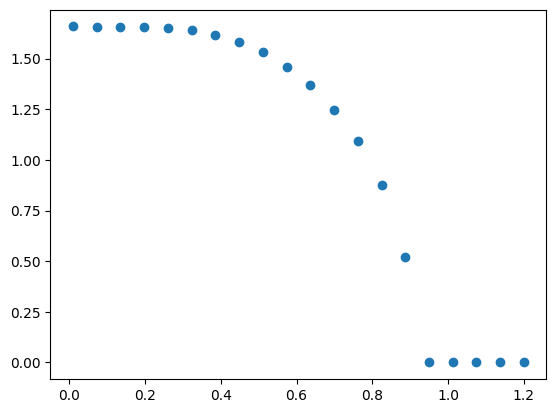

In [8]:
plt.scatter(temp_list,gap_list[:,0])
print(jnp.max(gap_list[:,0]))

### Checking current code and reflectivity code by making sure linear response above $T_C$ matches the normal state resistivity

In [3]:
cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1000

# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0* usadel.UsadelEvolution.get_bcs_ratio()

fine_nw = nw
fine_cutoff = cutoff

grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 1.0, 'time_sampling': 100}
system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': 0.5, 'z_t/R_n': 50/140}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 100}
sigma_scatterings = {'Phonon': 0.1} # {'Dynes': 0.0, 'Elastic': 0.0}
sigma_scatterings = None

run_temperature = 1.5

#* T_c in kelvin
T_c = 15.5 
#* write the current pulse in units of T_C. 
#*  FWHM = 1ps in 
t_pulse = 0.020 * T_c
print('T pulse is ', t_pulse)
current_function_gaussian = lambda t: np.exp(-(t - 0)**2 * np.log(2)/(t_pulse)**2) 

T pulse is  0.31


In [4]:
crt_pulse = lambda x: 0.1 * current_function_gaussian(x)
times, pulse_in, current_vs_time, gap_vs_time, q_vs_time = comp.real_time_evolve(run_temperature, current_function=crt_pulse, grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings)

100%|██████████| 99/99 [05:57<00:00,  3.61s/it]  


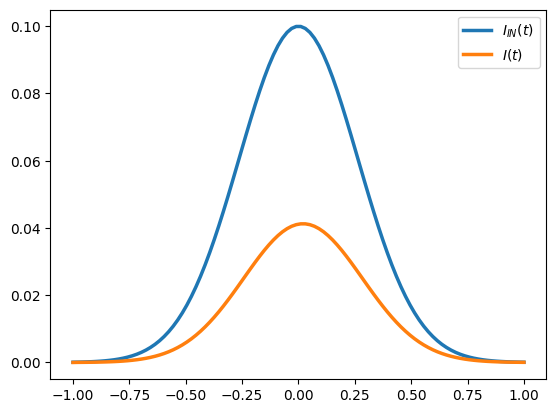

Transmitivity is 0.41260436
Theoretical_transmitivity is 0.4166666666666667


In [5]:
plt.plot(times , pulse_in, label = r'$I_{IN}(t)$', linewidth = 2.5) 
plt.plot(times, current_vs_time, label = r'$I(t)$', linewidth = 2.5)
plt.legend()
plt.show()

crt_pulse = lambda x: 0.1 * current_function_gaussian(x)
print('Transmitivity is', jnp.max(current_vs_time)/jnp.max(pulse_in))
print('Theoretical_transmitivity is', 2/(2 + 1/system_parameters['z_t/R_n']))

### Checking current code by making sure linear response matches the superfluid density, also check $2\pi$ factors in frequencies

In [6]:
cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1000
temp = 0.1, 
phonon_scattering = 0.0
eta = 0.15

grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 5.0, 'time_sampling': 100}
system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': temp, 'z_t/R_n': 50/170, 'eta': eta}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 50}
sigma_scatterings = {'Phonon': phonon_scattering} # {'Dynes': 0.0, 'Elastic': 0.0}
sigma_scatterings = None

my_usadel = usadel.UsadelEvolution(grid_parameters, system_parameters, sigma_scatterings)

run_temperature = temp

#* T_c in kelvin
T_c = 15.5 
#* write the current pulse in units of T_C. 
#*  FWHM = 1ps in 
t_pulse = 0.0208 * T_c * 2 * jnp.pi #! should be times 2pi since we used hbar = 1 
print('T pulse is ', t_pulse)
current_function_gaussian = lambda t: np.exp(-(t - 0)**2 * np.log(2)/(t_pulse)**2) 

T pulse is  2.0256989430346986


In [7]:
temp_list = jnp.linspace(0.1, 1.2, 1)
Q_list = jnp.linspace(0.0,0.7,30)

gap_list, current_list = comp.calculate_equilibrium(temp_list, grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings,  Q_list = Q_list)


100%|██████████| 30/30 [08:18<00:00, 16.62s/it]


[1.5474952  1.5471091  1.5459512  1.5440156  1.5413054  1.5378147
 1.5335369  1.5284681  1.5225991  1.5159265  1.5084298  1.5001152
 1.4909486  1.4809351  1.4700868  1.4581759  1.4459902  1.4310516
 1.4196546  1.4059771  1.3922803  1.2668934  1.294412   1.1992311
 1.0609952  0.9225052  0.7996932  0.68066573 0.549788   0.37763408]


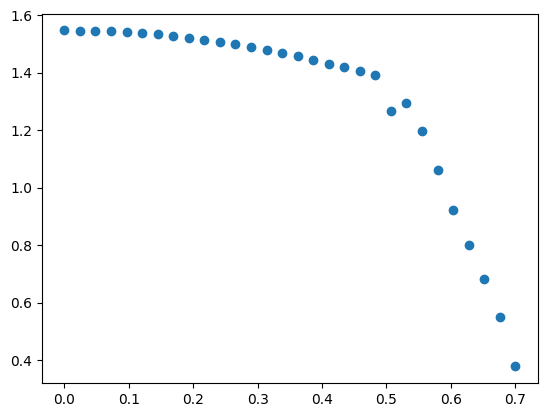

[0.         0.10742389 0.21461308 0.321332   0.4273508  0.53243136
 0.6363345  0.7388281  0.83966213 0.93861157 1.0354044  1.1298364
 1.2216016  1.3105001  1.3963537  1.4782737  1.5584849  1.6287979
 1.7101164  1.7835101  1.8540267  1.5379611  1.7498702  1.5385405
 1.2179879  0.9383848  0.7291719  0.5517267  0.3784421  0.18869984]


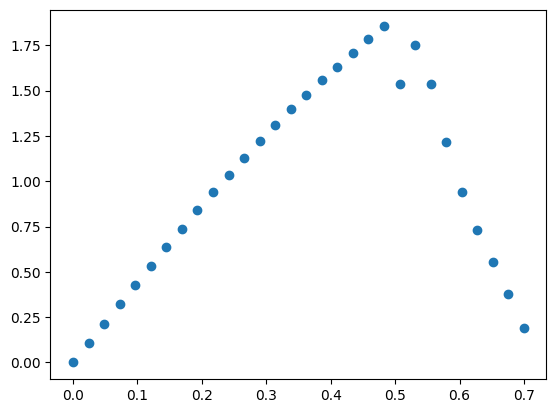

MAXIMUM CURRENT IS 1.8540267
linear proprotionality is 4.4504185
rough linear proprotionality theory is 4.8616


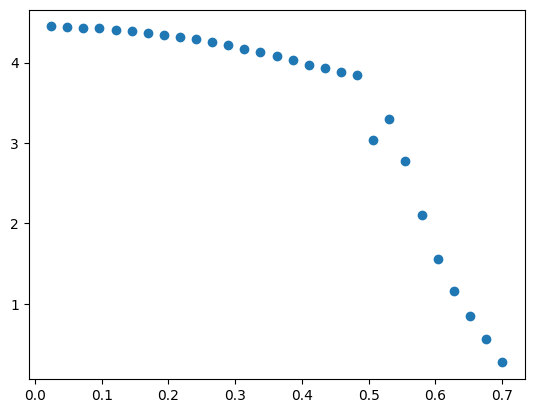

In [13]:

#print(gap_list)
#plt.scatter(temp_list,gap_list)
plt.scatter(Q_list,gap_list.T)
print(gap_list[0])
plt.show()
print(current_list[0])
plt.scatter(Q_list,current_list[0].real)
plt.show()
plt.scatter(Q_list,current_list[0].real/Q_list)
#plt.plot(Q_list,np.abs(gap_list.T[0])* (1 - Q_list**2/gap_list.T[0]/2) ** (3/2), 'k--')


CURRENT_MAXIMUM = jnp.max(current_list[0])

print('MAXIMUM CURRENT IS', CURRENT_MAXIMUM)

print('linear proprotionality is', jnp.max((current_list[0].real/Q_list)[1:]))
print('rough linear proprotionality theory is', jnp.max(gap_list) * jnp.pi)

In [14]:
system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.8540267, 'temperature': temp, 'z_t/R_n': 50/170, 'eta': eta}

crt_pulse = lambda x: 0.1 * current_function_gaussian(x)

times, pulse_in, current_vs_time, gap_vs_time, q_vs_time = comp.real_time_evolve(0.1, current_function=crt_pulse, grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings)

100%|██████████| 99/99 [11:24<00:00,  6.91s/it] 


In [21]:
fft_params = {'gap': 4.4504185/np.pi, 'z_t/R_n': 50/170}
frequencies, current_fft, current_trans, linear_voltage = linear_circuit_response( times = times, parameters = fft_params, current_function = crt_pulse)


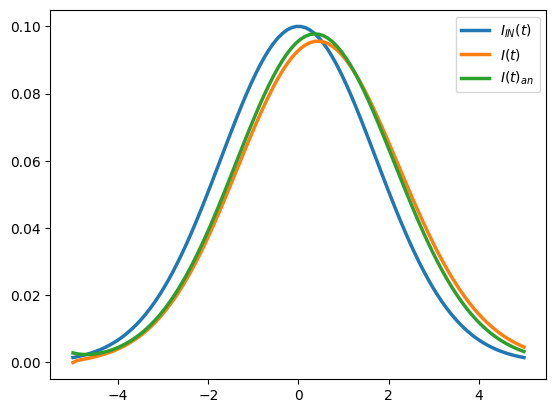

Transmitivity is 0.95632905
Linear response transmitivity is (0.9780233+1.8851479e-08j)


In [22]:
plt.plot(times , pulse_in, label = r'$I_{IN}(t)$', linewidth = 2.5) 
plt.plot(times, current_vs_time, label = r'$I(t)$', linewidth = 2.5)
plt.plot(times, np.real(current_trans), label = r'$I(t)_{an}$', linewidth = 2.5)

plt.legend()
plt.show()
print('Transmitivity is', jnp.max(current_vs_time)/jnp.max(pulse_in))
print('Linear response transmitivity is', jnp.max(current_trans)/jnp.max(pulse_in))


### Checking $\Sigma^{ph, (R)}_{\epsilon}$ by computing phonon scattering near $T_c$, i.e. $\Delta \ll T$